# DBSCAN Clustering

This notebook runs DBSCAN on preprocessed features and evaluates parameter combinations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, v_measure_score

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
X_scaled = pd.read_csv(os.path.join('data', 'data_preprocessed.csv'))
raw_df = pd.read_csv(os.path.join('data', 'Shopping Mall Customer Segmentation Data .csv'))
reference_labels = raw_df['Gender'].astype(str)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
X_scaled.head()

Scaled feature matrix shape: (15079, 4)


,Age,Gender,Annual_Income,Spending_Score
0,-0.666667,0.0,0.465394,0.775510
1,0.111111,-1.0,0.835265,0.897959
2,0.222222,-1.0,-0.421253,0.510204
3,-0.861111,0.0,-0.591304,0.122449
4,-0.833333,0.0,0.490409,0.510204


In [3]:
rows = []
eps_values = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        cluster_mask = labels != -1
        cluster_labels_only = labels[cluster_mask]
        unique_clusters = np.unique(cluster_labels_only)
        n_clusters = len(unique_clusters)
        noise_ratio = float(np.mean(labels == -1))

        if n_clusters >= 2 and cluster_mask.sum() > n_clusters:
            silhouette = silhouette_score(X_scaled[cluster_mask], cluster_labels_only)
        else:
            silhouette = np.nan

        v_measure = v_measure_score(reference_labels, labels.astype(str))

        rows.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette': silhouette,
            'v_measure_vs_gender': v_measure
        })

scores_df = pd.DataFrame(rows).sort_values(['silhouette', 'n_clusters'], ascending=[False, False])
scores_df

,eps,min_samples,n_clusters,noise_ratio,silhouette,v_measure_vs_gender
0,0.15,5,2,0.000597,0.217027,0.996093
5,0.20,15,2,0.000133,0.216961,0.998985
3,0.20,5,2,0.000000,0.216938,1.000000
4,0.20,10,2,0.000000,0.216938,1.000000
6,0.25,5,2,0.000000,0.216938,1.000000
7,0.25,10,2,0.000000,0.216938,1.000000
8,0.25,15,2,0.000000,0.216938,1.000000
9,0.30,5,2,0.000000,0.216938,1.000000
10,0.30,10,2,0.000000,0.216938,1.000000
11,0.30,15,2,0.000000,0.216938,1.000000


Best eps: 0.15
Best min_samples: 5
Clusters found (excluding noise): 2
Noise ratio: 0.0006
Silhouette: 0.21702717605934585
V-measure vs Gender: 0.9961


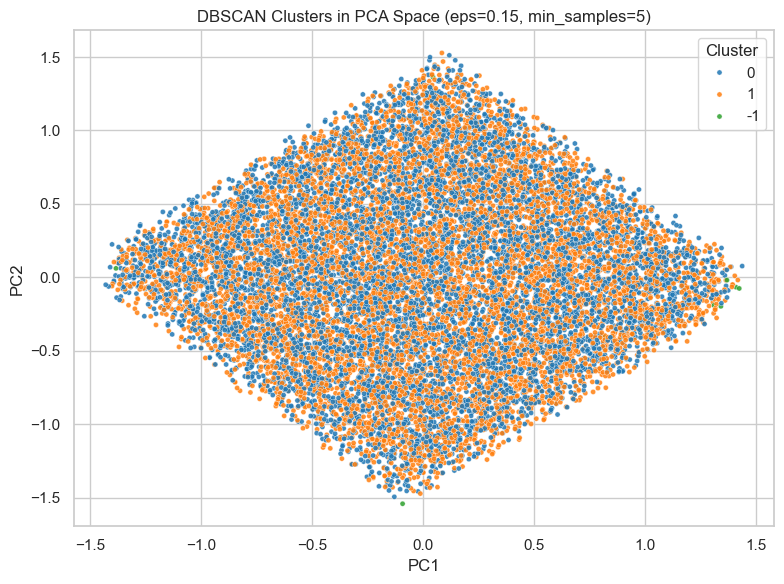

In [4]:
valid_scores = scores_df.dropna(subset=['silhouette'])
if not valid_scores.empty:
    best_row = valid_scores.iloc[0]
else:
    best_row = scores_df.sort_values(['noise_ratio', 'n_clusters'], ascending=[True, False]).iloc[0]

best_eps = float(best_row['eps'])
best_min_samples = int(best_row['min_samples'])

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_clustered_df = X_scaled.copy()
dbscan_clustered_df['Cluster'] = dbscan_labels

cluster_mask = dbscan_labels != -1
cluster_labels_only = dbscan_labels[cluster_mask]
if len(np.unique(cluster_labels_only)) >= 2 and cluster_mask.sum() > len(np.unique(cluster_labels_only)):
    final_silhouette = silhouette_score(X_scaled[cluster_mask], cluster_labels_only)
else:
    final_silhouette = np.nan

final_v_measure = v_measure_score(reference_labels, dbscan_labels.astype(str))

print(f'Best eps: {best_eps}')
print(f'Best min_samples: {best_min_samples}')
print(f'Clusters found (excluding noise): {len(np.unique(cluster_labels_only))}')
print(f'Noise ratio: {np.mean(dbscan_labels == -1):.4f}')
print(f'Silhouette: {final_silhouette}')
print(f'V-measure vs Gender: {final_v_measure:.4f}')

pca = PCA(n_components=2, random_state=42)
vis_df = pd.DataFrame(pca.fit_transform(X_scaled), columns=['PC1', 'PC2'])
vis_df['Cluster'] = dbscan_labels.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=vis_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=14, alpha=0.85)
plt.title(f'DBSCAN Clusters in PCA Space (eps={best_eps}, min_samples={best_min_samples})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

In [5]:
output_path = os.path.join('data', 'dbscan_clustered_data.csv')
dbscan_clustered_df.to_csv(output_path, index=False)
print(f'Saved DBSCAN clustered data to: {output_path}')

Saved DBSCAN clustered data to: data\dbscan_clustered_data.csv
